In [29]:
import numpy as np
import pandas as pd



from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install split-folders
!pip install torch-summary


In [4]:
labels_df=pd.read_csv('/content/drive/MyDrive/ML/metadata.csv')
print(labels_df.head().to_markdown())


|    |   Unnamed: 0 | image           | class   | format   | mode   | shape         |
|---:|-------------:|:----------------|:--------|:---------|:-------|:--------------|
|  0 |            0 | Cancer (1).jpg  | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  1 |            1 | Cancer (1).png  | tumor   | PNG      | L      | (300, 240)    |
|  2 |            2 | Cancer (1).tif  | tumor   | TIFF     | RGB    | (256, 256, 3) |
|  3 |            3 | Cancer (10).jpg | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  4 |            4 | Cancer (10).tif | tumor   | TIFF     | RGB    | (256, 256, 3) |


In [5]:

labels_df.shape

(4600, 6)

In [6]:
import splitfolders

data_dir = '/content/drive/MyDrive/ML/Brain Tumor Data Set/Brain Tumor Data Set'
splitfolders.ratio(
    data_dir,
    output='brain_data',
    seed=42,
    ratio=(0.8, 0.1, 0.1)   # TRAIN / VAL / TEST
)

TRAIN_DIR = 'brain_data/train'
VAL_DIR   = 'brain_data/val'
TEST_DIR  = 'brain_data/test'

Copying files: 4600 files [02:15, 33.98 files/s] 


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 3679 images belonging to 2 classes.
Found 459 images belonging to 2 classes.
Found 462 images belonging to 2 classes.


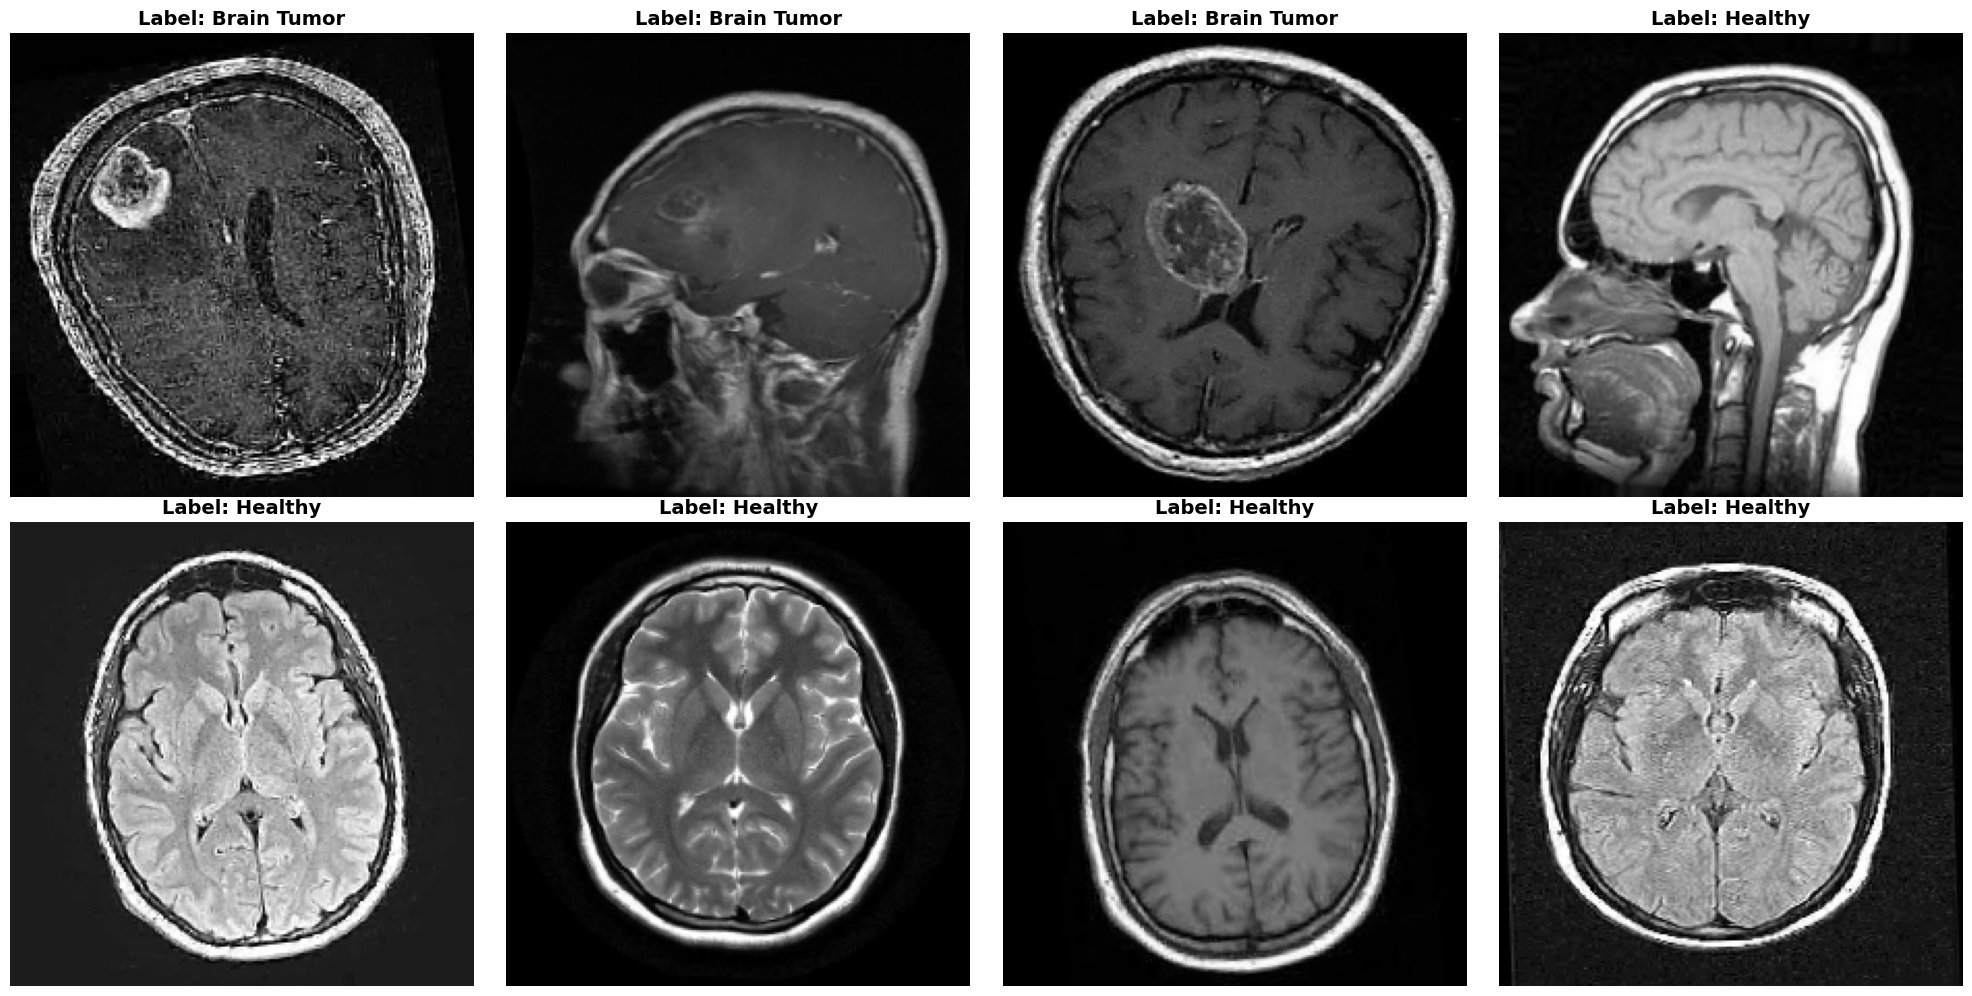

In [14]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_generator)


class_dict = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(20, 10))

for i in range(8):
    ax = plt.subplot(2, 4, i + 1)


    plt.imshow(images[i])


    label_index = int(labels[i])


    label_name = class_dict[label_index]

    plt.title(f"Label: {label_name}", color='black', fontsize=14, fontweight='bold')


    plt.axis("off")

plt.tight_layout()
plt.show()

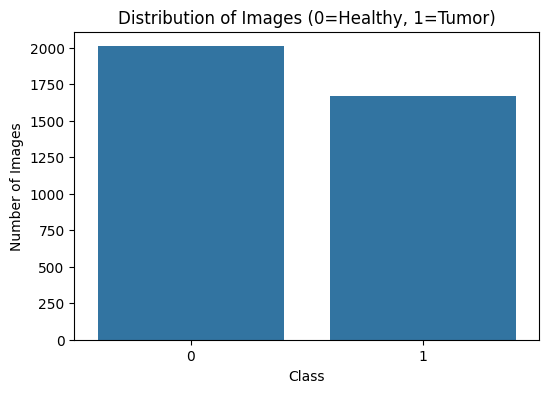

Number of Images Healthy (0): 2010
Number of Images Tumor (1): 1669


In [15]:
import seaborn as sns


real_labels = train_generator.classes


plt.figure(figsize=(6, 4))
sns.countplot(x=real_labels)
plt.title('Distribution of Images (0=Healthy, 1=Tumor)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

print("Number of Images Healthy (0):", len(real_labels[real_labels == 0]))
print("Number of Images Tumor (1):", len(real_labels[real_labels == 1]))

In [17]:

from keras import models
from keras import layers
from keras import optimizers

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation ='relu', input_shape =(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation ='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation ='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation ='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation ='relu'))
model.add(layers.Dense(1, activation ="sigmoid"))
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)



model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,679,041 (36.92 MB)

 Trainable params: 9,679,041 (36.92 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
steps_per_epoch = train_generator.samples // train_generator.batch_size
val_steps = val_gen.samples // val_gen.batch_size

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=40,
    validation_data=val_gen,
    validation_steps=val_steps
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 62s 474ms/step - accuracy: 0.6276 - loss: 0.6286 - val_accuracy: 0.7857 - val_loss: 0.4701
Epoch 2/40
  1/114 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7812 - loss: 0.4305

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7812 - loss: 0.4305 - val_accuracy: 0.7902 - val_loss: 0.4638
Epoch 3/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 46s 407ms/step - accuracy: 0.7856 - loss: 0.4601 - val_accuracy: 0.8192 - val_loss: 0.3928
Epoch 4/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9062 - loss: 0.3231 - val_accuracy: 0.8237 - val_loss: 0.3905
Epoch 5/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 48s 419ms/step - accuracy: 0.8334 - loss: 0.3710 - val_accuracy: 0.8504 - val_loss: 0.3446
Epoch 6/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9062 - loss: 0.2897 - val_accuracy: 0.8616 - val_loss: 0.3332
Epoch 7/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 46s 408ms/step - accuracy: 0.8540 - loss: 0.3325 - val_accuracy: 0.8906 - val_loss: 0.2980
Epoch 8/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9375 - loss: 0.2352 - val_accuracy: 0.8929 - val_loss: 0.2974
Epoch 9/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 48s 415ms/step - accuracy: 0.8730 - loss: 0.2845 - val_accuracy: 

(1, 224, 224, 3)


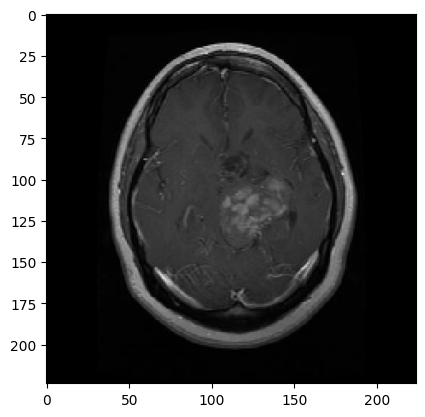

In [38]:
from keras.preprocessing import image
import numpy as np
import os # Import the os module for path manipulation

# Construct the correct path using TRAIN_DIR
image_path = os.path.join(TRAIN_DIR, 'Brain Tumor', 'Cancer (1).jpg')


img = image.load_img(image_path, target_size = (224, 224))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis = 0)
img_tensor = img_tensor / 255.


print(img_tensor.shape)


import matplotlib.pyplot as plt
plt.imshow(img_tensor[0])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
(1, 222, 222, 32)


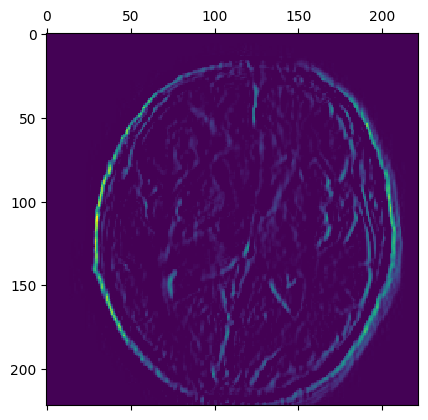

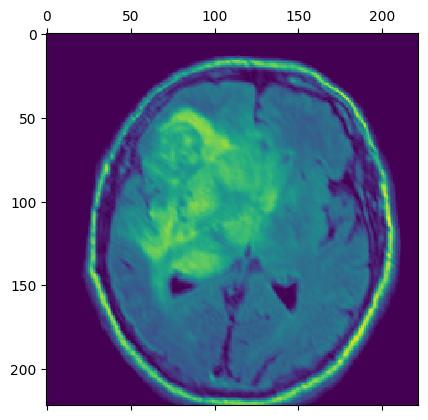

In [30]:
import numpy as np # Ensure numpy is imported for array operations
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

# Ensure the model is built before accessing its input
# The input shape should match the input expected by the model (150, 150, 3) plus a batch dimension (None)
if not model.built:
    model.build(input_shape=(None, 150, 150, 3))


if 'train_generator' in locals():
    images, _ = next(train_generator)
    img_tensor = np.expand_dims(images[0], axis=0)
else:
    print("Error: 'train_generator' is not defined. Please run the cell where it is initialized.")

    img_tensor = np.random.rand(1, 224, 224, 3).astype('float32')

# Outputs of the 8 layers, which include conv2D and max pooling layers
layer_outputs = [layer.output for layer in model.layers[:8]]
activation_model = models.Model(inputs = model.layers[0].input, outputs = layer_outputs)
activations = activation_model.predict(img_tensor)


first_layer_activation = activations[0]

# shape of first layer activation
print(first_layer_activation.shape)


plt.matshow(first_layer_activation[0, :, :, 6], cmap ='viridis')


plt.matshow(first_layer_activation[0, :, :, 15], cmap ='viridis')


In [31]:
layer_names = []

for layer in model.layers[:8]:
  layer_names.append(layer.name)
print(layer_names)


['conv2d_4', 'max_pooling2d_4', 'conv2d_5', 'max_pooling2d_5', 'conv2d_6', 'max_pooling2d_6', 'conv2d_7', 'max_pooling2d_7']


In [32]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model

layer_names = [layer.name for layer in model.layers[:8]]


if not model.built:
    model.build(input_shape=(None, 224, 224, 3))


layer_outputs = [model.get_layer(name).output for name in layer_names]


activation_model = Model(inputs=model.layers[0].input, outputs=layer_outputs)


if 'img_tensor' not in locals():
    print("Warning: 'img_tensor' not found. Please ensure it's defined or run previous cells.")

    img_tensor = np.random.rand(1, 150, 150, 3).astype('float32')

activations = activation_model.predict(img_tensor)


images_per_row = 8

for layer_name, layer_activation in zip(layer_names, activations):

    # layer_activation shape is (1, height, width, n_features)
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]

    # We tile the activation channels in this matrix
    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    # Fill the grid with the filter images
    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0, :, :, col * images_per_row + row]

            # Post-process the feature to make it visually pleasing
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')

            # Place into grid
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    # Display the grid
    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

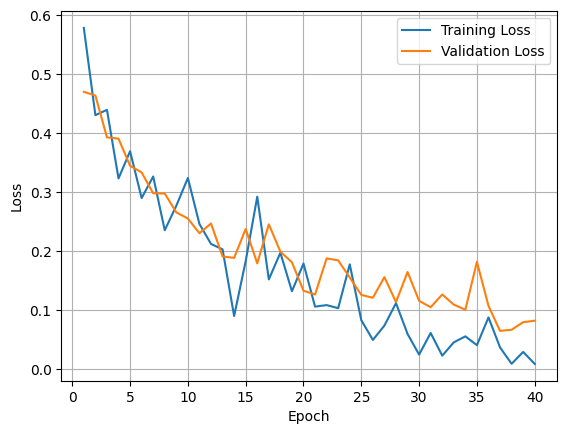

In [33]:
if 'history' in locals() and history is not None:
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(train_loss) + 1)

    plt.plot(epochs, train_loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Error: The 'history' object is not defined.")
    print("This usually happens if the model training cell (model.fit) was not executed, ")
    print("or if the kernel state was reset (e.g., by loading a new model) after training.")
    print("Please ensure the training cell (e.g., cell HH6LQ9mHSNk_ where model.fit is called) has been run recently ")
    print("and that this plotting cell is executed *before* any operations that might clear the kernel state.")



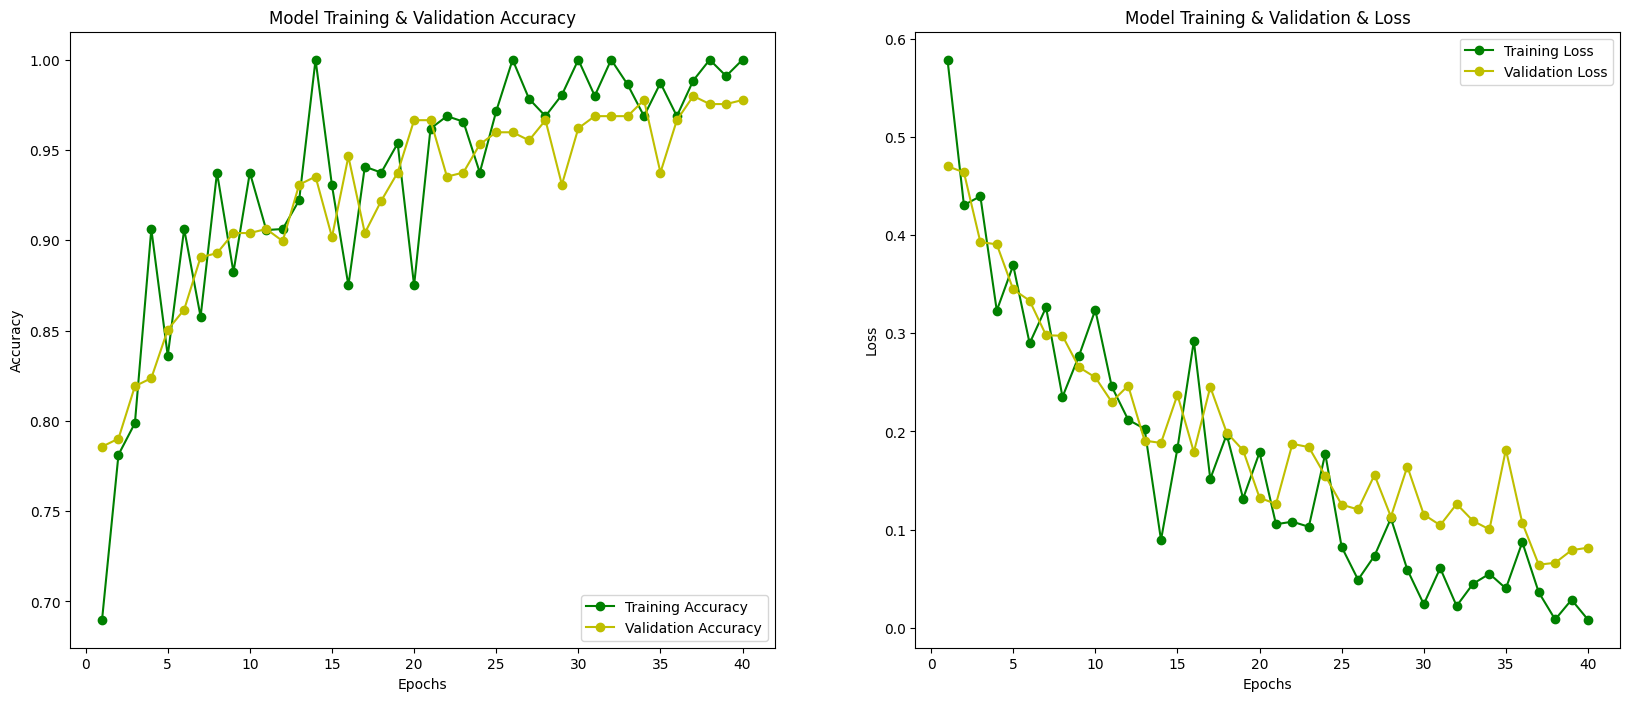

In [34]:
fig , ax = plt.subplots(1,2)
fig.set_size_inches(20, 8)

train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

ax[0].plot(epochs , train_acc , 'g-o' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'y-o' , label = 'Validation Accuracy')
ax[0].set_title('Model Training & Validation Accuracy')
ax[0].legend(loc = 'lower right')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'y-o' , label = 'Validation Loss')
ax[1].set_title('Model Training & Validation & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

plt.show()

Se calculează predicțiile...
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step

Matricea de Confuzie (Valori):
[[247   4]
 [  6 202]]


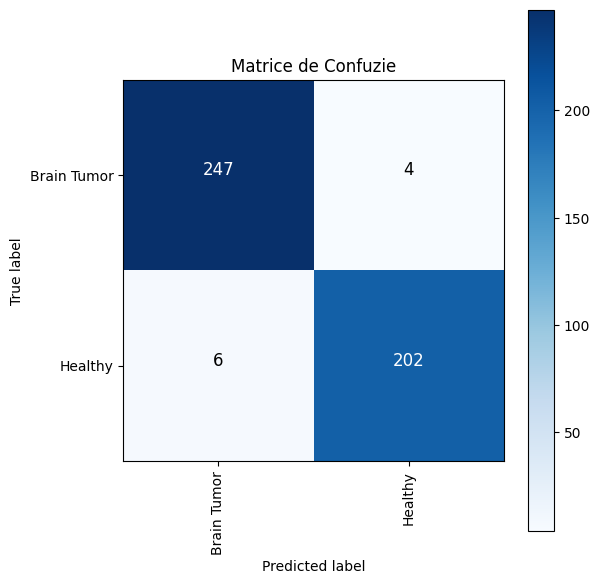

In [35]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize = False,
                          title = 'Confusion Matrix',
                          cmap = plt.cm.Blues):

    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    plt.grid(False)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 fontsize = 12,
                 horizontalalignment = "center",
                 color = "white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


test_data = val_gen

test_data.shuffle = False
test_data.reset()


y_test = test_data.classes

# B. Facem predicția
print("Se calculează predicțiile...")
y_pred_probs = model.predict(test_data, verbose=1)


yhat_test = (y_pred_probs > 0.5).astype(int).reshape(-1)


cm = confusion_matrix(y_test, yhat_test)
print("\nMatricea de Confuzie (Valori):")
print(cm)


classes_names = list(test_data.class_indices.keys())


plot_confusion_matrix(cm, classes_names, normalize=False, title='Matrice de Confuzie')


In [36]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize = False,
                          title = 'Confusion Matrix',
                          cmap = plt.cm.Blues):

    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    plt.grid(False)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 fontsize = 12,
                 horizontalalignment = "center",
                 color = "white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


In [37]:
from sklearn.metrics import classification_report
#get classification report
print(classification_report(y_test, yhat_test))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       251
           1       0.98      0.97      0.98       208

    accuracy                           0.98       459
   macro avg       0.98      0.98      0.98       459
weighted avg       0.98      0.98      0.98       459

